**Lab 6: IIR Filtering**


The objective for this lab is to help you understand the relationship between the location
of poles and zeros in the z-domain, the impulse response h[n] in the n-domain, and the frequency
response $H(e^{j\omega})$. We use the system function,
represented as a ratio of polynomials in $z^{-1}$, which can be expressed in either factored or expanded form as:

$$
H(z) = G\frac{\prod_{k=1}^M (1-z_kz^{-1}) }{\prod_{k=1}^N (1-p_kz^{-1})} = \frac{ \sum_{k=0}^M b_kz^{-k}}{ 1- \sum_{k=1}^N a_kz^{-k} }
$$

In [1]:
import numpy as np
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_frequency_response

**1. IIR filters to extract the envelope**

In the previous labs, you extracted the envelope from your reference signal by applying the following system:

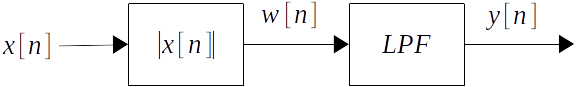

where $w[n] = |x[n]|$ and $y[n]$ was the output of a low-pass FIR filter (averaging filter). In this exercise, you will re-implement this low-pass filter as an IIR.

1.1 First, copy the functions envelope and synthesize from previous work and obtain the same synthesis. 



In [2]:
#Cridem les dues funcions del Lab4
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi)
  return y

def envelope(x, N):
    b = np.ones(N)/N    #Crea un array de longitud N on tots els valors són 1 i ho dividim tot entre N
    x = np.abs(x)       #Fem l'absolut del senyal x
    y = np.convolve(x, b, mode = "same") #Fem la convolució
    return y

#Carreguem el fitxer
filepath = "audio/so_guitarra.wav"
ref, fs = load_audio(filepath)

#Declarem les variables
f0 = 656.7627
fs = 44100
phi = np.pi
weights = [0.5979, 0.4226, 0.7496, 0.8093, 0.4654, 1, 0.5842, 0.2608]
t = np.linspace(0, len(ref) / fs, len(ref)) #Durada de 0 a 1 segon amb fs mostres per segon

#Cridem les funcions que acabem de copiar
syn = synthesize(f0, phi, weights, t)   
y = envelope(ref, N=500)

#Fem la convolució
syn_Lab4 = syn * y

1.2 Let's take a look at the following system:

$$
H(z) = G\frac{1+z^{-1}}{1-rz^{-1}} \quad   0<r<1 \quad, G = \frac{1-r}{2}
$$

Note that the coefficients of the filter are the following:

$$
b_0 = 1, \quad b_1 = 1, \quad a_0 = 1, \quad a_1 = -r, \quad
$$

i. Find the zeros and poles of the system analytically.

Sabem que trobem els zeros quan el numerador és 0 i trobem els pols quan el denominador és 0. Aleshores, haurem d'analitzar els dos casos.
Prèviament, reescrivim H(z):

$$H(z) = G\frac{1+z^{-1}}{1-rz^{-1}} = \frac{1-r}{2}\frac{1+z^{-1}}{1-rz^{-1}} = \frac{(1-r)(1+z^{-1})}{2(1-rz^{-1})}  \
$$

$\textbf{Zeros:}$

Podem observar que el numerador està format per dos polinomis, per tant hem d'analitzar quan cada un d'ells dona zero.

- El primer polinomi, (1 - r), mai dona zero perquè l'enunciat estableix que 0 < r < 1.

- El segon polinomi, dona zero quan $$(1 + z^{-1}) = 0$$, és a dir, quan z = -1.


$\textbf{Pols:}$

Perquè el denominador sigui zero, s'ha de complir que $$(1 - rz^{-1}) = 0$$, és a dir, quan z = r.

ii. Use the function `np.roots` to find the zeros and poles using Python. Compare the results with part i.

In [ ]:
r = 0.8 #Definim un r qualsevol, sempre i quan compleixi la condició inicial, 0 < r < 1

#Definim el numerador i denominador amb els coeficients
numerador = [1,1]
denominador = [1, -r]

#Trobem els zeros i pols
zeros = np.roots(numerador)
pols = np.roots(denominador)

print("Els zeros són: ", zeros)
print("Els pols són: ", pols)

Els zeros són:  [-1.]
Els pols són:  [0.8]


iii. Use the function  `plot_zeros_poles(z, p)` to plot the zeros and poles found in ii.

In [4]:
from util import plot_zeros_poles

plot_zeros_poles(zeros, pols)

1.3 Let's see the frequency response of this filter:



In [18]:
from scipy.signal import freqz

r = 0.8 #Definim un r qualsevol, sempre i quan compleixi la condició inicial, 0 < r < 1

#Definim el numerador i denominador amb els coeficients
G = (1-r)/2
numerador = [G, G]
denominador = [1, -r]

interval = np.linspace(-np.pi, np.pi, 2048)
w, h = freqz(numerador, denominador, worN = interval)
plot_frequency_response(w, h)


1.4. Change the parameter $r$ in the range $(0, 1)$. What happens when $r$ is increased?

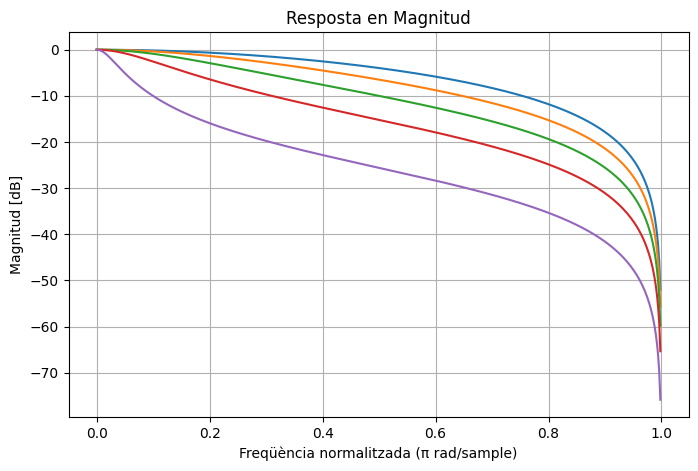

In [ ]:
#Definim diferents valors per r
r_values = [0.1, 0.3, 0.5, 0.7, 0.9]

plt.figure(figsize=(8,5))

for r in r_values:
    numerador = [(1-r), (1-r)]
    denominador = [2, -2*r]

    w, h = freqz(numerador, denominador)

    plt.plot(w/np.pi, 20*np.log10(abs(h)))


plt.title('Resposta en Magnitud')
plt.xlabel('Freqüència normalitzada (π rad/sample)')
plt.ylabel('Magnitud [dB]')
plt.grid(True)

plt.show()

Podem observar com a mesura que r incrementa, el filtre accentua les baixes freqüències i atenua les altes freqüències. 

1.5 What type of filter is (low-pass, band-pass, or high-pass filter)?


Per tant, és un filtre passa-baixes (low-pass filter).

1.6 Now we can use this IIR filter to extract the envelope. Let's define a new function `envelope_iir(x)` that applies the filter to the absolute value of the signal. Note that we are using signal.lfilter function to apply the filter.


In [19]:
from scipy.signal import lfilter

#Definim la funció per trobar l'envelope d'un senyal
def envelope_iir(x, r=0.995):
    #Definim el numerador i denominador (Coeficients del filtre IIR)
    G = (1 - r) / 2
    numerador = [G, G]
    denominador = [1, -r]

    #Apliquem el filtre al valor absolut del senyal
    env = lfilter(numerador, denominador, np.abs(x))
    #Retornem l'envelope obtingut
    return env

Extract the envelope of your reference signal using both the FIR and IIR filters and compare the results plot them along with the signal. Change the value of $r$ until you are comfortable with the result.

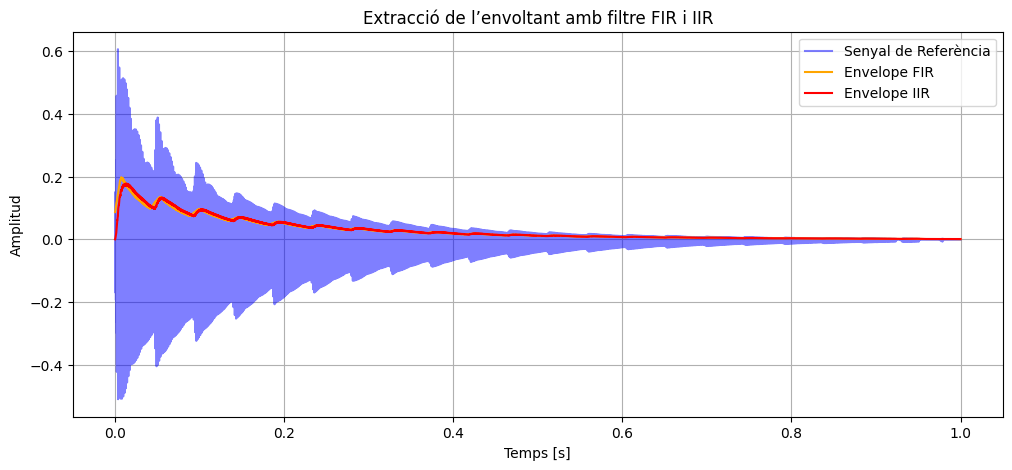

In [13]:
#Carreguem el fitxer
filepath = "audio/so_guitarra.wav"
ref, fs = load_audio(filepath)

#Declarem les variables
fs = 44100
t = np.linspace(0, len(ref) / fs, len(ref)) #Durada de 0 a 1 segon amb fs mostres per segon

#Ho extraiem amb el filtre FIR
envelope_fir_reference = envelope(ref, N = 500)
#Ho estraiem amb el filtre IIR
envelope_iir_reference = envelope_iir(ref, r =0.995)

#Dibuixem els senyals
plt.figure(figsize=(12,5))
plt.plot(t, ref, label="Senyal de Referència", color= "blue", alpha = 0.5)
plt.plot(t, envelope_fir_reference, label="Envelope FIR", color= "orange")
plt.plot(t, envelope_iir_reference, label="Envelope IIR", color= "red")
plt.title('Extracció de l’envoltant amb filtre FIR i IIR')
plt.xlabel('Temps [s]')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()


1.7 What are the main differences between the two filters? For instance, compare the number of coefficients.

?????????????
Podem observar com els dos filtres són bastant semblants. 

Els filtres FIR utilitzen només mostres d’entrada i necessiten molts coeficients per suavitzar l’envoltant, mentre que els IIR són recursius, utilitzen també mostres passades de sortida i aconsegueixen suavitat similar amb molt menys coeficients. 

Fir agafa N mostres i iir agafa 4

1.8 Apply the new envelope (extracted from the IIR filter) to the synthesis generated with the `synthesize` function and listen to the result.

In [14]:
from IPython.display import Audio

f0 = 656.7627
fs = 44100
phi = np.pi
weights = [0.5979, 0.4226, 0.7496, 0.8093, 0.4654, 1, 0.5842, 0.2608]
t = np.linspace(0, len(ref) / fs, len(ref)) #Durada de 0 a 1 segon amb fs mostres per segon

syn_envelope = synthesize(f0, phi, weights, t)
signal_final = syn_envelope * envelope_iir_reference

print("Importem l'Envelope Signal IIR")
display(Audio(signal_final, rate = fs)) #Escoltem el l'Envelope Signal IIR

Importem l'Envelope Signal IIR


---

**2. Band-pass filters**

Now let's work with the following system: 

$$
H(z) = \frac{(1-z^{-1})(1+z^{-1})}{(1-re^{j\omega_n}z^{-1})(1-re^{-j\omega_n}z^{-1})}, \quad 0<r<1
$$

Note that the poles are $p_1 = re^{j\omega_n}$ and $p_2 = re^{-j\omega_n}$; and the zeros are $z_1=1$ and $z_2=-1$. 

2.1 Use the function `plot_zeros_poles` to plot the zeros and poles of the system.

Note: use $w_n = \pi/4$ and $r=0.99$.

In [17]:
r = 0.99
zeros = [1, -1]
pols = [r*np.exp(-1j*np.pi/4), r*np.exp(1j*np.pi/4)]

plot_zeros_poles(zeros, pols)

2.2 Show analytically that $a_k = [1, -2rcos(\omega_n), r^2]$ and $b_k=[1, 0, -1]$.

[Double click to write your answer]

2.3 Plot the frequency response of the filter. Confirm this is a band-pass filter. What's the central frequency of the passband?

In [21]:
from scipy.signal import freqz

r=0.99
w_n = np.pi / 4

b = [1, 0, -1]
a = [1, -2*r*np.cos(w_n), r**2]

interval = np.linspace(-np.pi, np.pi)
w, H = signal.freqz(b, a, worN=interval)
plot_frequency_response(w, H)

[Double click to write your answer]


2.4 Define a function `bpf(x, f, r, fs)` that applies the above band-pass filter. 

Note 1: remember that a frequency can be converted to the normalized radian frequncy by: $\omega_n = 2\pi f_n/f_s$.

Note 2: use `signal.lfilter` function to implement the filter.

In [26]:
def bpf(x, fn, fs, r=0.995):
  """Applies a band-pass filter with central frequency fn

  Parameters
  ----------
  x : np.array
      The input signal in the form of a numpy array
  fn: int or float
      Central frequency of the band pass in Hz 
  fs : int or float
      Frequency rate in Hz
  r: float
      Magnitude of the poles

  Returns
  -------
  y : np.array
      The output of the filter

  """
  w_n = 2 * np.pi * fn / fs 
  b = [1, 0, -1]  #Coeficients del numerador
  a = [1, -2 * r * np.cos(w_n), r ** 2]  #Coeficients del denominador
  y = signal.lfilter(b, a, x) #Utilitzem la funció lfilter
  return y

2.5 Regardless of the phase, until now we were synthesizing the instrument signal by summing $K$ harmonics of the signal with different weights ($A_k$) and multiplying the sum by the envelope of the reference signal ($e(t)$):

$$y(t) = e(t) \cdot \sum_{k=1}^K A_k\cos\left(2\pi kf_0 t \right), $$

where $f_0$ is the fundamental frequency of the note. Now we want to improve this synthesis by finding a time-dependent amplitude ($A_k(t)$) for each harmonic:

$$y(t) = \sum_{k=1}^K A_k(t) \cos\left(2\pi kf_0 t \right), $$

where $A_k(t)$ is the amplitude of the harmonic $k$. To extract the amplitudes $A_k(t)$ we'll apply a band-pass filter with central frequency $kf_0$ and calculate the envelope of the output by using the `envelope_iir`.


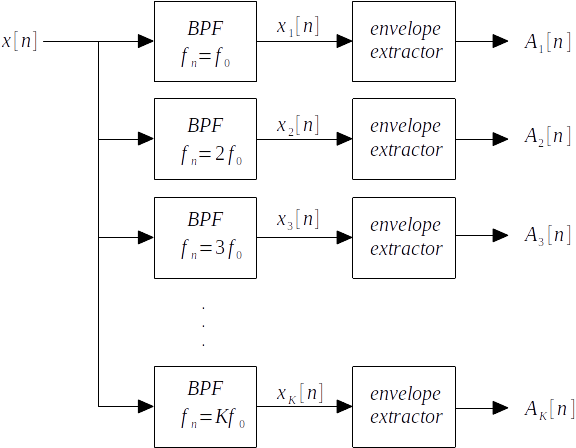

For instance, the following code should extract the envelope of the fundamental frequency component. Change the value of $f_0$ to coincide with your fundamental frequency and check the result. 

In [32]:
f0 = 656.7627

y = bpf(ref, f0, fs, r=0.995)
output = envelope_iir(y, r=0.7)
plot_signals(y=[ref, y, output],sr=fs,name=['Senyal de Referència', 'Filtrat BPF (f0)', 'Envelope A1(t)'])

2.6 Complete the `synthetize_with_bpf` function to implement a synthesis applying different envelopes for each harmonic.


In [33]:
def synthetize_with_bpf(x, f0, phi, K, fs):
  """Synthetizes an harmonic signal using different envelopes for each harmonic
  The envelops are extracted from the reference signal x.

  Parameters
  ----------
  x : np.array
      The reference signal in the form of a numpy array
  f0: int or float
      Fundamental frequency of the synthesis
  phi : float
      Phase
  K: int
      Number of harmonics
  fs : int or float
      Frequency rate in Hz

  Returns
  -------
  y : np.array
      The output of the filter

  """
  t = np.linspace(0, len(x) / fs, len(x), endpoint=False)
  y = np.zeros_like(x)
  for k in range(1, K + 1):
    x_k = bpf(x, k * f0, fs, r=0.995) #Filtre passa-banda centrat a k*f0 
    A_k = envelope_iir(x_k, r=0.7) #Envolve del k-èssim harmònic: A_k(t)
    y += A_k * np.cos(2 * np.pi * k * f0 * t + k * phi)
  return y

2.6 Call the function `synthetize_with_bpf` to get the synthesized signal and **listen to it**.

Note that now you can increase the number of harmonics $K$ as you want because we are not manually measuring the weights of each harmonic.

In [37]:
fs = 44100
f0 = 656.7627
phi = np.pi
K = 10

y_synth = synthetize_with_bpf(ref, f0, phi, K, fs)

print("Importem el ##############")
display(Audio(y_synth, rate=fs))


Importem el ##############


2.7 Compare the **spectrograms** of the synthesized signal and reference signal.

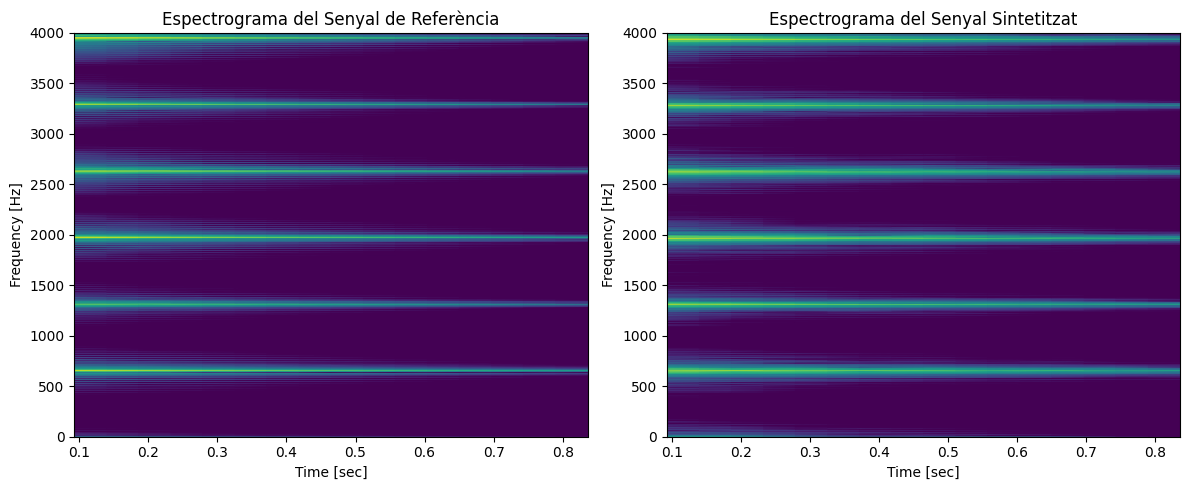

In [40]:
from scipy.signal import spectrogram 









from scipy.signal import spectrogram 

window_length = 8192 #Definim el nombre de mostres

#Calculem els espectrogrames, el del senyal de referència i el del senyal sintetitzat
ff, tt, S_ref = spectrogram(ref, fs, nperseg=window_length, noverlap=window_length / 2)
ff_syn, tt_syn, S_syn = spectrogram(y_synth, fs, nperseg=window_length, noverlap=window_length / 2)

#Creem la figura, ja que la dividirem en dos
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plot_spectrogram(ff, tt, S_ref)
plt.title('Espectrograma del Senyal de Referència')
plt.ylim([0, 4000])

plt.subplot(1,2,2)
plot_spectrogram(ff_syn, tt_syn, S_syn)
plt.title('Espectrograma del Senyal Sintetitzat')
plt.ylim([0, 4000])

plt.tight_layout()
plt.show()